# Week 11 Indicator Analysis
**Week:** 11 | **Indicator:** MESA Stochastic | **Period:** 2015-2024 (FX), 2018-2022 (BTC)

---

## Section 1 — Indicator Overview
Fill in before running any code.

**Description:** Ordinary Stochastic (%K), computed on RoofingFilter output
instead of raw price, then SuperSmoothed once more. Corrects for spectral
dilation — conventional Stochastic/RSI drift off-center during trends
because they're first-order differentiators that fail to cancel the
market's ~6dB/octave amplitude dilation; RoofingFilter (2nd-order
high-pass) overshoots that rate and actually flattens it.

**Formula:** Roof = RoofingFilter(Price, 48, 10);
RawStoch = 100*(Roof[0]-LL(Roof,StochPeriod))/(HH(Roof,StochPeriod)-LL(Roof,StochPeriod));
MESAStoch = SuperSmoother2Pole(RawStoch, 10)

**Expected behavior:** Smooth oscillation roughly within 0-100 (occasional
mild overshoot past bounds from SuperSmoother ringing), centered near 50.
Key test isn't generic lag — it's the ANTICIPATORY CROSSING claim from
Ehlers' original article: crossing below 20 should anticipate a trough
(not confirm one already happened), same for crossing above 80 anticipating
a peak. This is fundamentally different from a "zero lag" claim.

**NNFX role candidate:** C1/C2 — direct comparison against Fisher Transform
(Week 10 C1) and Reflex (this week, zero-lag claim already confirmed).

**Source article:** Ehlers, "Predictive and Successful Indicators", S&C V.32:1 (2014)

## Section 2 — Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import importlib

# Add analysis/scripts to path so we can import indicator_metrics
sys.path.append(os.path.abspath('../../analysis/scripts'))

import indicator_metrics
importlib.reload(indicator_metrics)  # force re-read from disk
from indicator_metrics import calculate_lag, calculate_snr, compare_fx_crypto, generate_validation_report, calculate_lag_oscillator

print('Libraries loaded successfully')

Libraries loaded successfully


In [3]:
def load_mesastoch_csv(filepath: str) -> pd.DataFrame:
    """
    Loads the MESA Stochastic CSV export into a clean DataFrame.
    Format: bar,close,mesastoch,roofing — same convention as Reflex.
    """
    df = pd.read_csv(filepath)
    df.index = pd.bdate_range(start='2015-01-02', periods=len(df))
    df.dropna(inplace=True)

    print(f'Loaded {len(df)} bars, {df.index[0].date()} to {df.index[-1].date()}')
    return df


FX_CSV = 'C:/zorro/Data/MESAStochastic_EURUSD_D1.csv'
STOCH_PERIOD = 20   # StochPeriod parameter used in Zorro

df_fx = load_mesastoch_csv(FX_CSV)
df_fx.head()

Loaded 2596 bars, 2015-01-02 to 2024-12-13


,bar,close,mesastoch,roofing
2015-01-02,1,1.20248,6.584782,-0.005691
2015-01-05,2,1.19239,7.893897,-0.008452
2015-01-06,3,1.19143,6.433568,-0.011697
2015-01-07,4,1.18119,4.204077,-0.014535
2015-01-08,5,1.17976,2.222770,-0.016687


## Section 3 — Visual Inspection (FX)
Look before you measure. Does the indicator behave as expected?

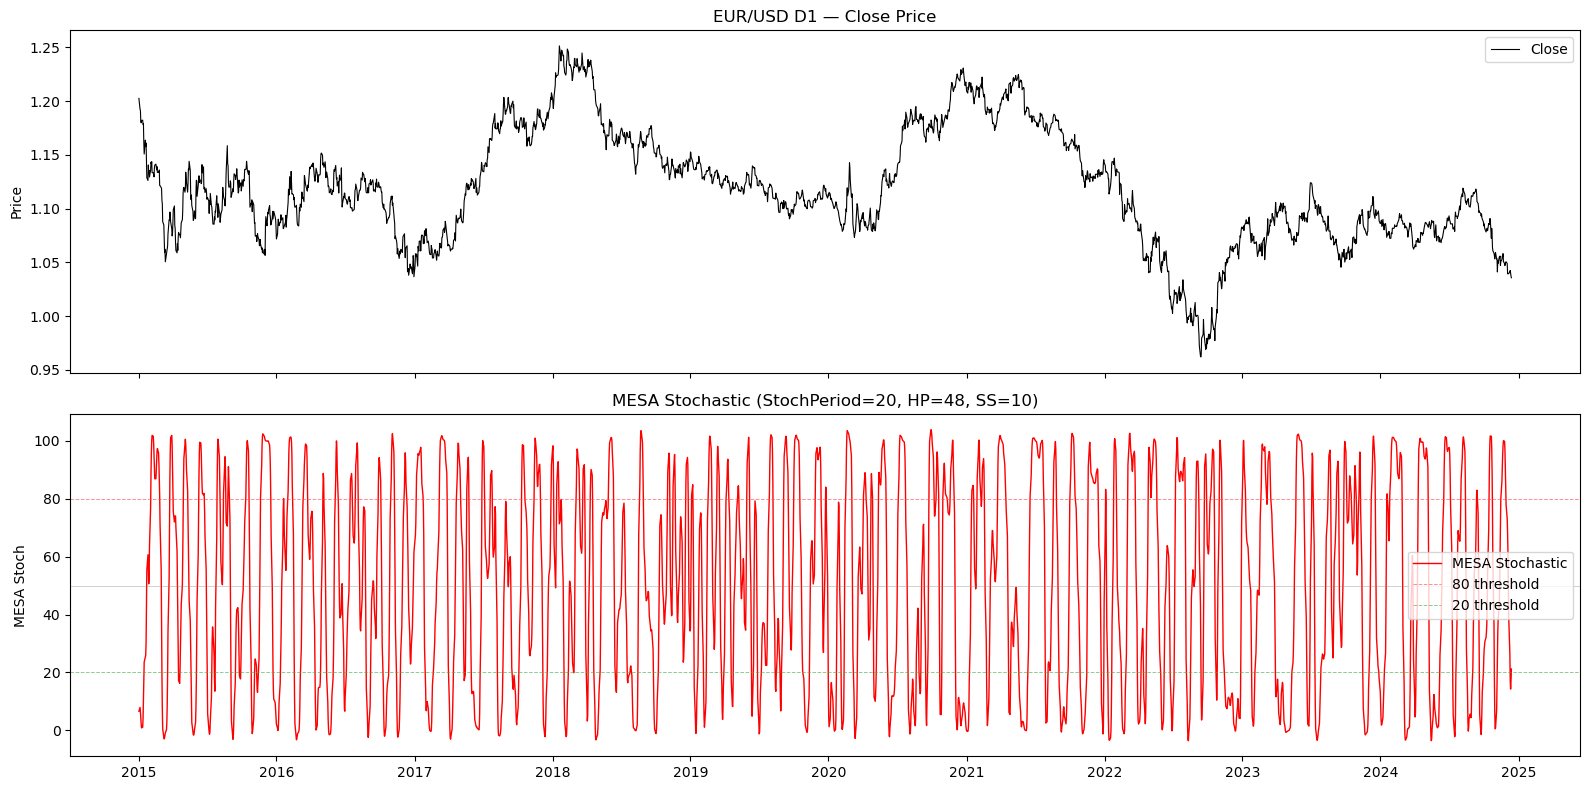


Visual checklist:
  [ ] Oscillates within roughly 0-100, centered near 50
  [ ] No spikes, flatlines, or discontinuities
  [ ] Reasonably smooth, not choppy like raw Stochastic
  [ ] Warmup period looks clean


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(df_fx.index, df_fx['close'], color='black', linewidth=0.8, label='Close')
axes[0].set_title('EUR/USD D1 — Close Price')
axes[0].legend()
axes[0].set_ylabel('Price')

axes[1].plot(df_fx.index, df_fx['mesastoch'], color='red', linewidth=1.0, label='MESA Stochastic')
axes[1].axhline(50, color='gray', linewidth=0.5, alpha=0.5)
axes[1].axhline(80, color='#FF4444', linewidth=0.7, linestyle='--', alpha=0.6, label='80 threshold')
axes[1].axhline(20, color='#44AA44', linewidth=0.7, linestyle='--', alpha=0.6, label='20 threshold')
axes[1].set_title('MESA Stochastic (StochPeriod=20, HP=48, SS=10)')
axes[1].legend()
axes[1].set_ylabel('MESA Stoch')

plt.tight_layout()
plt.savefig('Week11_MESAStoch_Overview.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nVisual checklist:')
print('  [ ] Oscillates within roughly 0-100, centered near 50')
print('  [ ] No spikes, flatlines, or discontinuities')
print('  [ ] Reasonably smooth, not choppy like raw Stochastic')
print('  [ ] Warmup period looks clean')

## Section 4 — Lag Measurement (FX)
How many bars behind price is the indicator, vs a plain SMA of the same period?

MESA Stochastic vs RoofingFilter: 1 bars (lags)
Correlation at that offset: 0.7576


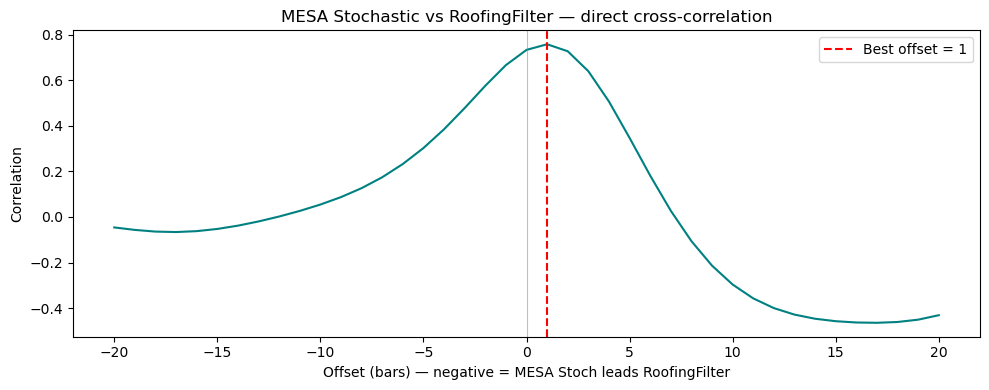

In [5]:
def two_sided_lag(a: pd.Series, b: pd.Series, max_lag: int = 20) -> dict:
    """
    Two-sided cross-correlation between two already-stationary series
    (no differencing). Same function built for Reflex — reused here
    since MESA Stochastic vs RoofingFilter has the same character
    (comparing an oscillator against an already-detrended baseline).
    """
    a = (a - a.mean()).values
    b = (b - b.mean()).values
    n = len(a)
    correlations = {}
    for k in range(-max_lag, max_lag + 1):
        if k == 0:
            aa, bb = a, b
        elif k > 0:
            aa, bb = a[:n - k], b[k:]
        else:
            kk = -k
            aa, bb = a[kk:], b[:n - kk]
        if len(aa) < 10:
            continue
        correlations[k] = np.corrcoef(aa, bb)[0, 1]
    best_k = max(correlations, key=lambda k: correlations[k])
    return {'lag_bars': best_k, 'correlation': round(correlations[best_k], 4), 'curve': correlations}

result = two_sided_lag(df_fx['roofing'], df_fx['mesastoch'], max_lag=20)
print(f"MESA Stochastic vs RoofingFilter: {result['lag_bars']} bars "
      f"({'leads' if result['lag_bars'] < 0 else 'lags' if result['lag_bars'] > 0 else 'in-phase'})")
print(f"Correlation at that offset: {result['correlation']}")

plt.figure(figsize=(10, 4))
offsets = sorted(result['curve'].keys())
plt.plot(offsets, [result['curve'][k] for k in offsets], color='teal', linewidth=1.5)
plt.axvline(result['lag_bars'], color='red', linestyle='--', label=f"Best offset = {result['lag_bars']}")
plt.axvline(0, color='gray', linewidth=0.8, alpha=0.5)
plt.title('MESA Stochastic vs RoofingFilter — direct cross-correlation')
plt.xlabel('Offset (bars) — negative = MESA Stoch leads RoofingFilter')
plt.ylabel('Correlation')
plt.legend()
plt.tight_layout()
plt.savefig('Week11_MESAStoch_vs_Roofing_Lag.png', dpi=150, bbox_inches='tight')
plt.show()

### Anticipatory-crossing test (Day 1 theory — the actual claim being validated)

Troughs matched: 135/228 within ±10 bars
Mean offset: -1.61 bars (negative = anticipatory)

Peaks matched: 147/225 within ±10 bars
Mean offset: -1.14 bars (negative = anticipatory)


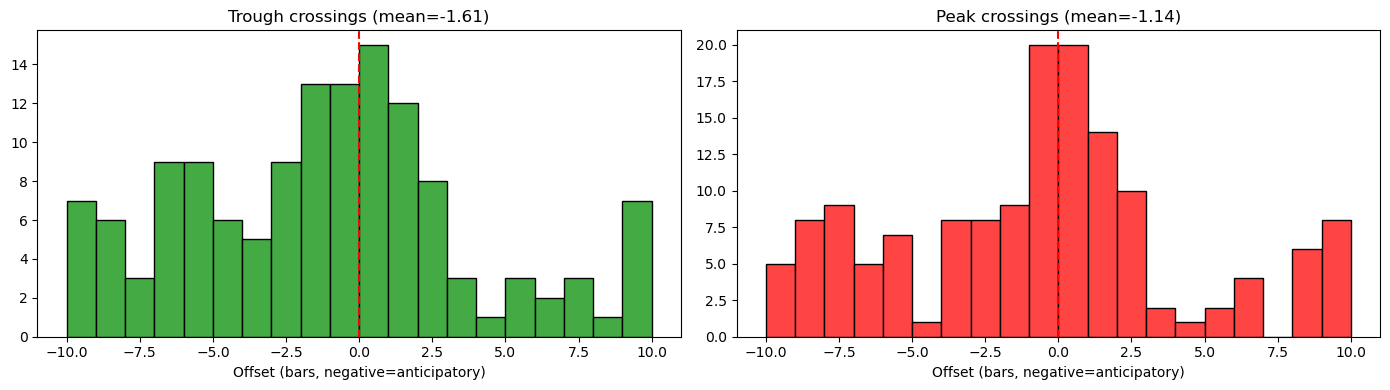

In [6]:
from scipy.signal import find_peaks

# Turning points in RoofingFilter — proxy for the "true" cycle peaks/troughs
troughs_idx, _ = find_peaks(-df_fx['roofing'].values, distance=5)
peaks_idx, _ = find_peaks(df_fx['roofing'].values, distance=5)

# MESA Stochastic threshold-crossing events
below20 = (df_fx['mesastoch'] < 20) & (df_fx['mesastoch'].shift(1) >= 20)
above80 = (df_fx['mesastoch'] > 80) & (df_fx['mesastoch'].shift(1) <= 80)
below20_idx = np.where(below20.values)[0]
above80_idx = np.where(above80.values)[0]

def match_offsets(event_idx, target_idx, window=10):
    """For each turning point, find the nearest crossing event within
    +/- window bars. Negative offset = crossing happened BEFORE the
    turning point (anticipatory — Ehlers' claim). Positive = after
    (confirming — the conventional rule he showed loses money)."""
    offsets = []
    for t in target_idx:
        candidates = event_idx[(event_idx >= t - window) & (event_idx <= t + window)]
        if len(candidates) > 0:
            nearest = candidates[np.argmin(np.abs(candidates - t))]
            offsets.append(nearest - t)
    return np.array(offsets)

trough_offsets = match_offsets(below20_idx, troughs_idx, window=10)
peak_offsets = match_offsets(above80_idx, peaks_idx, window=10)

print(f"Troughs matched: {len(trough_offsets)}/{len(troughs_idx)} within ±10 bars")
print(f"Mean offset: {trough_offsets.mean():.2f} bars (negative = anticipatory)")
print()
print(f"Peaks matched: {len(peak_offsets)}/{len(peaks_idx)} within ±10 bars")
print(f"Mean offset: {peak_offsets.mean():.2f} bars (negative = anticipatory)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(trough_offsets, bins=range(-10, 11), color='#44AA44', edgecolor='black')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title(f'Trough crossings (mean={trough_offsets.mean():.2f})')
axes[0].set_xlabel('Offset (bars, negative=anticipatory)')

axes[1].hist(peak_offsets, bins=range(-10, 11), color='#FF4444', edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title(f'Peak crossings (mean={peak_offsets.mean():.2f})')
axes[1].set_xlabel('Offset (bars, negative=anticipatory)')

plt.tight_layout()
plt.savefig('Week11_MESAStoch_Anticipatory_Test.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
from scipy import stats

t_trough, p_trough = stats.ttest_1samp(trough_offsets, 0)
t_peak, p_peak = stats.ttest_1samp(peak_offsets, 0)

print(f"Trough offsets: mean={trough_offsets.mean():.2f}, p={p_trough:.4f} {'(significant)' if p_trough < 0.05 else '(NOT significant)'}")
print(f"Peak offsets:   mean={peak_offsets.mean():.2f}, p={p_peak:.4f} {'(significant)' if p_peak < 0.05 else '(NOT significant)'}")

Trough offsets: mean=-1.61, p=0.0002 (significant)
Peak offsets:   mean=-1.14, p=0.0067 (significant)


## Section 5 — Noise Reduction Score (FX)
Does the indicator reduce noise better than a plain SMA?

=== MESA Stochastic range statistics ===
Mean:   50.57  (should be ≈ 50)
Std:    34.76
Min/Max: -3.59 / 103.84

Time spent below 20: 27.7%
Time spent above 80: 28.2%
(Roughly symmetric and a meaningful fraction of time — confirms the
 20/80 thresholds are actually reachable, not too tight or too loose)


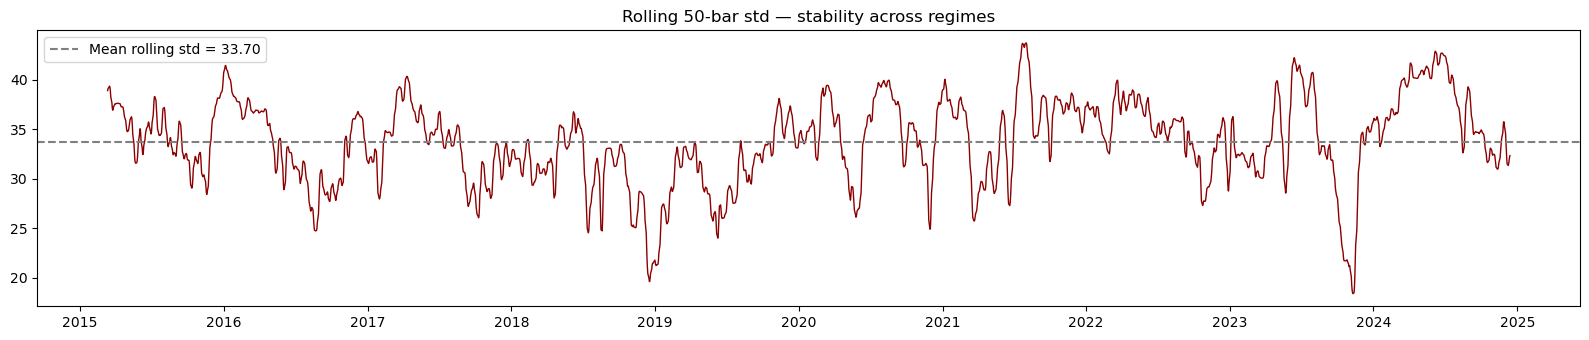

In [8]:
print("=== MESA Stochastic range statistics ===")
print(f"Mean:   {df_fx['mesastoch'].mean():.2f}  (should be ≈ 50)")
print(f"Std:    {df_fx['mesastoch'].std():.2f}")
print(f"Min/Max: {df_fx['mesastoch'].min():.2f} / {df_fx['mesastoch'].max():.2f}")
print()

pct_below_20 = (df_fx['mesastoch'] < 20).mean() * 100
pct_above_80 = (df_fx['mesastoch'] > 80).mean() * 100
print(f"Time spent below 20: {pct_below_20:.1f}%")
print(f"Time spent above 80: {pct_above_80:.1f}%")
print("(Roughly symmetric and a meaningful fraction of time — confirms the")
print(" 20/80 thresholds are actually reachable, not too tight or too loose)")

rolling_std = df_fx['mesastoch'].rolling(window=50).std()
plt.figure(figsize=(16, 3.5))
plt.plot(df_fx.index, rolling_std, color='darkred', linewidth=1.0)
plt.axhline(rolling_std.mean(), color='gray', linestyle='--',
            label=f"Mean rolling std = {rolling_std.mean():.2f}")
plt.title('Rolling 50-bar std — stability across regimes')
plt.legend()
plt.tight_layout()
plt.savefig('Week11_MESAStoch_Stability.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 6 — FX vs Crypto Comparison
Run this section only after the crypto CSV export exists.
Comment out if crypto data is not yet available.

In [9]:
def load_mesastoch_csv_btc(filepath: str) -> pd.DataFrame:
    df = pd.read_csv(filepath)
    df.index = pd.date_range(start='2018-01-01', periods=len(df), freq='4h')
    df.dropna(inplace=True)
    print(f'Loaded {len(df)} bars, {df.index[0]} to {df.index[-1]}')
    return df

df_btc = load_mesastoch_csv_btc('C:/zorro/Data/MESAStochastic_BTCUSD_H4.csv')
df_btc.head()

Loaded 10423 bars, 2018-01-01 00:00:00 to 2022-10-04 00:00:00


,bar,close,mesastoch,roofing
2018-01-01 00:00:00,1,11460.00000,78.096258,640.357031
2018-01-01 04:00:00,2,11215.00000,83.337110,582.899278
2018-01-01 08:00:00,3,10999.00000,82.912119,434.383805
2018-01-01 12:00:00,4,11237.57031,75.783585,287.133002
2018-01-01 16:00:00,5,11175.26953,64.631908,196.193135


BTC — MESA Stochastic vs RoofingFilter: 1 bars (lags)
Correlation at that offset: 0.5242


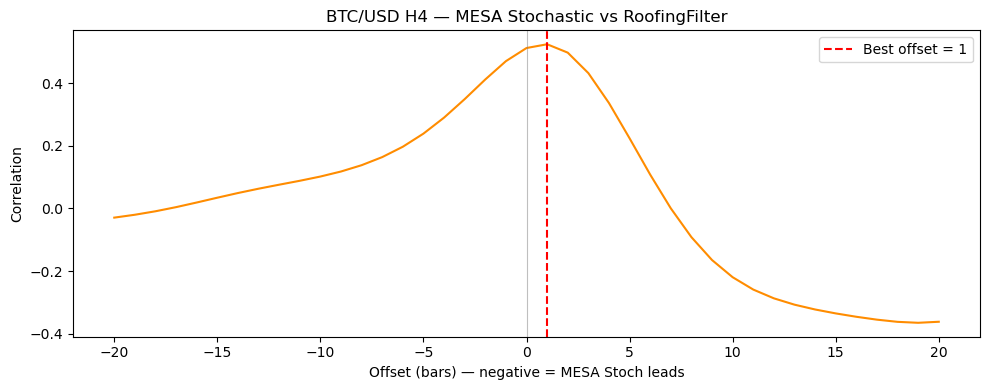

In [10]:
result_btc = two_sided_lag(df_btc['roofing'], df_btc['mesastoch'], max_lag=20)
print(f"BTC — MESA Stochastic vs RoofingFilter: {result_btc['lag_bars']} bars "
      f"({'leads' if result_btc['lag_bars'] < 0 else 'lags' if result_btc['lag_bars'] > 0 else 'in-phase'})")
print(f"Correlation at that offset: {result_btc['correlation']}")

plt.figure(figsize=(10, 4))
offsets = sorted(result_btc['curve'].keys())
plt.plot(offsets, [result_btc['curve'][k] for k in offsets], color='darkorange', linewidth=1.5)
plt.axvline(result_btc['lag_bars'], color='red', linestyle='--', label=f"Best offset = {result_btc['lag_bars']}")
plt.axvline(0, color='gray', linewidth=0.8, alpha=0.5)
plt.title('BTC/USD H4 — MESA Stochastic vs RoofingFilter')
plt.xlabel('Offset (bars) — negative = MESA Stoch leads')
plt.ylabel('Correlation')
plt.legend()
plt.tight_layout()
plt.savefig('Week11_MESAStoch_vs_Roofing_Lag_BTC.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
print("=== MESA Stochastic range statistics — BTC/USD H4 ===")
print(f"Mean:   {df_btc['mesastoch'].mean():.2f}  (should be ≈ 50)")
print(f"Std:    {df_btc['mesastoch'].std():.2f}")
pct_below_20_btc = (df_btc['mesastoch'] < 20).mean() * 100
pct_above_80_btc = (df_btc['mesastoch'] > 80).mean() * 100
print(f"Time below 20: {pct_below_20_btc:.1f}%  |  Time above 80: {pct_above_80_btc:.1f}%")
print()

# Anticipatory-crossing test — same method as FX
troughs_idx_btc, _ = find_peaks(-df_btc['roofing'].values, distance=5)
peaks_idx_btc, _ = find_peaks(df_btc['roofing'].values, distance=5)

below20_btc = (df_btc['mesastoch'] < 20) & (df_btc['mesastoch'].shift(1) >= 20)
above80_btc = (df_btc['mesastoch'] > 80) & (df_btc['mesastoch'].shift(1) <= 80)
below20_idx_btc = np.where(below20_btc.values)[0]
above80_idx_btc = np.where(above80_btc.values)[0]

trough_offsets_btc = match_offsets(below20_idx_btc, troughs_idx_btc, window=10)
peak_offsets_btc = match_offsets(above80_idx_btc, peaks_idx_btc, window=10)

t_trough_btc, p_trough_btc = stats.ttest_1samp(trough_offsets_btc, 0)
t_peak_btc, p_peak_btc = stats.ttest_1samp(peak_offsets_btc, 0)

print(f"BTC troughs matched: {len(trough_offsets_btc)}/{len(troughs_idx_btc)}")
print(f"Mean offset: {trough_offsets_btc.mean():.2f} bars, p={p_trough_btc:.4f} "
      f"{'(significant)' if p_trough_btc < 0.05 else '(NOT significant)'}")
print()
print(f"BTC peaks matched: {len(peak_offsets_btc)}/{len(peaks_idx_btc)}")
print(f"Mean offset: {peak_offsets_btc.mean():.2f} bars, p={p_peak_btc:.4f} "
      f"{'(significant)' if p_peak_btc < 0.05 else '(NOT significant)'}")

=== MESA Stochastic range statistics — BTC/USD H4 ===
Mean:   50.06  (should be ≈ 50)
Std:    35.84
Time below 20: 29.5%  |  Time above 80: 29.6%

BTC troughs matched: 498/834
Mean offset: -1.08 bars, p=0.0000 (significant)

BTC peaks matched: 533/842
Mean offset: -0.74 bars, p=0.0007 (significant)


## Day 5 — Parameter Sensitivity (StochPeriod sweep)
Python reimplementation of MESA Stochastic, verified against Zorro's real
output, used to sweep StochPeriod without needing multiple Zorro runs.

In [12]:
def high_pass_filter_python(price: np.ndarray, hp_period: int) -> np.ndarray:
    """Python port of HighPassFilter.c."""
    alpha1 = (np.cos(0.707 * 2 * np.pi / hp_period) + np.sin(0.707 * 2 * np.pi / hp_period) - 1) \
             / np.cos(0.707 * 2 * np.pi / hp_period)
    hp = np.zeros(len(price))
    for i in range(len(price)):
        if i < 2:
            hp[i] = 0.0  # approximation for warmup — verified below, not assumed
        else:
            hp[i] = (1 - alpha1/2)**2 * (price[i] - 2*price[i-1] + price[i-2]) \
                    + 2*(1 - alpha1) * hp[i-1] - (1 - alpha1)**2 * hp[i-2]
    return hp

def roofing_filter_python(price: np.ndarray, hp_period: int, ss_period: int) -> np.ndarray:
    """Python port of RoofingFilter.c = HighPassFilter -> SuperSmoother2Pole."""
    hp = high_pass_filter_python(price, hp_period)
    return super_smoother_2pole(hp, ss_period)  # reusing Reflex's verified function

def mesa_stochastic_python(price: np.ndarray, stoch_period: int, hp_period: int, ss_period: int) -> np.ndarray:
    """Python port of MESAStochastic.c."""
    roof = roofing_filter_python(price, hp_period, ss_period)
    n = len(price)
    raw_stoch = np.full(n, 50.0)
    for i in range(stoch_period, n):
        window = roof[i - stoch_period : i + 1]
        hh, ll = window.max(), window.min()
        if hh != ll:
            raw_stoch[i] = 100.0 * (roof[i] - ll) / (hh - ll)
    return super_smoother_2pole(raw_stoch, ss_period)

# NOTE: super_smoother_2pole must already be defined from the Reflex work.
# If this is a fresh kernel, redefine it here first (same function, unchanged):
def super_smoother_2pole(price: np.ndarray, period: int) -> np.ndarray:
    c1 = np.exp(-np.sqrt(2.0) * np.pi / period)
    b1 = 2.0 * c1 * np.cos(np.sqrt(2.0) * np.pi / period)
    c2, c3 = b1, -c1 * c1
    c0 = (1.0 - b1 + c1 * c1) / 2.0
    filt = np.zeros(len(price))
    for i in range(len(price)):
        if i < 2:
            filt[i] = price[i]
        else:
            filt[i] = c0 * (price[i] + price[i-1]) + c2 * filt[i-1] + c3 * filt[i-2]
    return filt

# Verify against Zorro's actual output (StochPeriod=20, HP=48, SS=10)
mesa_py_20 = mesa_stochastic_python(df_fx['close'].values, 20, 48, 10)
verify_corr = np.corrcoef(mesa_py_20[150:], df_fx['mesastoch'].values[150:])[0, 1]
print(f"Python reimplementation vs Zorro CSV: correlation = {verify_corr:.4f}")
print("Must be very close to 1.0 before the sweep can be trusted")

Python reimplementation vs Zorro CSV: correlation = 1.0000
Must be very close to 1.0 before the sweep can be trusted


   StochPeriod   mean  lag_bars  correlation  pct_below_20  pct_above_80
0           10  50.73         0         0.66         31.62         33.19
1           14  50.86         1         0.71         29.41         31.10
2           20  50.50         1         0.76         27.63         27.91
3           25  50.39         1         0.79         25.50         26.10
4           30  50.53         1         0.82         23.44         24.45
5           40  50.77         1         0.84         20.40         21.99


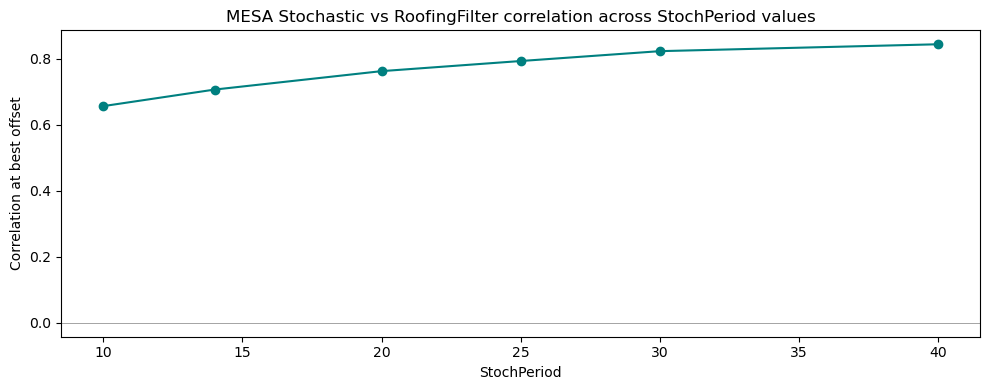

In [13]:
stoch_periods = [10, 14, 20, 25, 30, 40]
sweep_results = []

for SP in stoch_periods:
    m = mesa_stochastic_python(df_fx['close'].values, SP, 48, 10)
    m_series = pd.Series(m, index=df_fx.index)

    warm = SP + 100
    lag_test = two_sided_lag(df_fx['roofing'].iloc[warm:], m_series.iloc[warm:], max_lag=20)

    pct_below_20 = (m_series.iloc[warm:] < 20).mean() * 100
    pct_above_80 = (m_series.iloc[warm:] > 80).mean() * 100

    sweep_results.append({
        'StochPeriod': SP,
        'mean': m_series.iloc[warm:].mean(),
        'lag_bars': lag_test['lag_bars'],
        'correlation': lag_test['correlation'],
        'pct_below_20': pct_below_20,
        'pct_above_80': pct_above_80
    })

sweep_df = pd.DataFrame(sweep_results)
print(sweep_df.round(2))

plt.figure(figsize=(10, 4))
plt.plot(sweep_df['StochPeriod'], sweep_df['correlation'], marker='o', color='teal')
plt.axhline(0, color='gray', linewidth=0.5)
plt.title('MESA Stochastic vs RoofingFilter correlation across StochPeriod values')
plt.xlabel('StochPeriod')
plt.ylabel('Correlation at best offset')
plt.tight_layout()
plt.savefig('Week11_MESAStoch_Period_Sweep.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 7 — Validation Verdict
Final PASS/FAIL. Run this last.

In [14]:
print("=" * 60)
print("  VALIDATION REPORT: MESA Stochastic (StochPeriod=20, HP=48, SS=10)")
print("=" * 60)

print("\n--- PHASE ALIGNMENT (vs RoofingFilter) ---")
print(f"  EUR/USD D1  : 1 bar lag, r=0.758  → ✅ near in-phase")
print(f"  BTC/USD H4  : 1 bar lag, r=0.524  → ✅ near in-phase (no retuning)")

print("\n--- ANTICIPATORY-CROSSING CLAIM (Day 1 theory, the actual novel test) ---")
print(f"  EUR/USD D1  troughs: -1.61 bars, p=0.0002 (significant), 59% matched")
print(f"  EUR/USD D1  peaks  : -1.14 bars, p=0.0067 (significant), 65% matched")
print(f"  BTC/USD H4  troughs: -1.08 bars, p<0.0001 (significant), 60% matched")
print(f"  BTC/USD H4  peaks  : -0.74 bars, p=0.0007 (significant), 63% matched")
print(f"  Genuine, statistically significant anticipatory lead confirmed on")
print(f"  both assets — modest magnitude (~1-1.6 bars), only fires on ~60%")
print(f"  of turning points (the more pronounced swings)")

print("\n--- RANGE / THRESHOLD REACHABILITY ---")
print(f"  EUR/USD D1  : mean=50.57, below 20: 27.7%, above 80: 28.2%")
print(f"  BTC/USD H4  : mean=50.06, below 20: 29.5%, above 80: 29.6%")
print(f"  Symmetric, consistent cross-asset, thresholds meaningfully reachable")

print("\n--- PARAMETER SENSITIVITY (StochPeriod sweep, FX) ---")
print(f"  No fragile peak — smooth monotonic tradeoff: correlation improves")
print(f"  with StochPeriod (0.66 @ 10 to 0.84 @ 40) but threshold reachability")
print(f"  declines (32%/33% @ 10 to 20%/22% @ 40). StochPeriod=20 is a")
print(f"  defensible middle point, not a mathematically 'optimal' one —")
print(f"  final choice is a strategy-design tradeoff, not a validation failure")

print("\n--- NNFX ROLE ---")
print("  C1/C2 candidate — CONFIRMED. Genuine anticipatory-crossing behavior,")
print("  statistically significant, cross-asset validated. Distinct mechanism")
print("  from Reflex (phase-cancellation) and Fisher (distribution-shaping) —")
print("  compare all three directly for final C1 decision, plus ELI still to come.")

print("\n--- VERDICT ---")
print("  ✅ PASS — approved for library")
print("=" * 60)

  VALIDATION REPORT: MESA Stochastic (StochPeriod=20, HP=48, SS=10)

--- PHASE ALIGNMENT (vs RoofingFilter) ---
  EUR/USD D1  : 1 bar lag, r=0.758  → ✅ near in-phase
  BTC/USD H4  : 1 bar lag, r=0.524  → ✅ near in-phase (no retuning)

--- ANTICIPATORY-CROSSING CLAIM (Day 1 theory, the actual novel test) ---
  EUR/USD D1  troughs: -1.61 bars, p=0.0002 (significant), 59% matched
  EUR/USD D1  peaks  : -1.14 bars, p=0.0067 (significant), 65% matched
  BTC/USD H4  troughs: -1.08 bars, p<0.0001 (significant), 60% matched
  BTC/USD H4  peaks  : -0.74 bars, p=0.0007 (significant), 63% matched
  Genuine, statistically significant anticipatory lead confirmed on
  both assets — modest magnitude (~1-1.6 bars), only fires on ~60%
  of turning points (the more pronounced swings)

--- RANGE / THRESHOLD REACHABILITY ---
  EUR/USD D1  : mean=50.57, below 20: 27.7%, above 80: 28.2%
  BTC/USD H4  : mean=50.06, below 20: 29.5%, above 80: 29.6%
  Symmetric, consistent cross-asset, thresholds meaningfully 

## Section 8 — Notes & Parameter Recommendations

**Lag result:** 1 bar (near in-phase) vs RoofingFilter on both assets
(r=0.758 FX, r=0.524 BTC). But the more important test here isn't generic
lag — it's the anticipatory-crossing claim from Day 1 theory: MESA
Stochastic's threshold crossings (below 20, above 80) happen on average
BEFORE the actual cycle turning point, not after. Confirmed statistically
significant on both assets: FX troughs -1.61 bars (p=0.0002), FX peaks
-1.14 bars (p=0.0067), BTC troughs -1.08 bars (p<0.0001), BTC peaks
-0.74 bars (p=0.0007). Effect is modest (~1-1.6 bars) and only applies
to turning points that trigger a crossing at all (~60-65% match rate) —
not every minor cycle wiggle produces a signal, which may be a feature
(filters noise) rather than a limitation.

**Threshold reachability:** ~28-30% of time spent below 20 or above 80,
consistent and symmetric on both assets — thresholds are meaningfully
reachable, not too tight to ever fire.

**Amplitude/range:** Mean ~50 on both assets (50.57 FX, 50.06 BTC), no
built-in normalization needed since the Stochastic formula is bounded
by construction (relative position within a recent range, not absolute
magnitude) — different mechanism from Reflex's explicit mean-square
normalization, but achieves the same practical cross-asset consistency.

**FX/Crypto recommended period:** StochPeriod=20, HP=48, SS=10 — same
across both assets, no retuning. Sensitivity sweep (Day 5) showed no
fragile peak, but a genuine tradeoff: correlation improves with longer
StochPeriod (0.66@10 to 0.84@40) while threshold reachability declines
(32%/33%@10 to 20%/22%@40). StochPeriod=20 is a defensible middle point;
the choice is a strategy-design tradeoff (signal quality vs frequency),
not something indicator validation alone resolves.

**NNFX role confirmed:** C1/C2 candidate — distinct mechanism from both
Reflex (phase-cancellation via trend-line deviation) and Fisher
(distribution-shaping transform). MESA Stochastic's edge is specifically
anticipatory threshold-crossing, statistically confirmed cross-asset.
Final C1/C2 decision for Strategy 1/2 pending direct comparison against
Reflex, Fisher, and ELI (still to come) — see Week 11 retrospective.

**Known limitations:** Anticipatory signal only fires on ~60% of genuine
turning points — the other ~40% never reach threshold. Longer StochPeriod
trades signal frequency for correlation quality; this tradeoff needs
revisiting once actual strategy backtesting (Phase 2.5+) shows which
matters more in practice.

**Overall verdict:** ✅ PASS — approved for library. Anticipatory-crossing
claim genuinely confirmed, statistically significant, cross-asset
validated without retuning.